In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.2 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
from ultralytics import YOLO

modelo = YOLO('yolo11n.pt')

modelo.train(
    # Archivo yaml para definir el dataset.
    data="/content/drive/MyDrive/Sudoku/data.yaml",
    epochs=30,  # Numero de epocas que defino.
    batch=32,   #Tamaño de batch.
    imgsz=640,  # Tamaño de las imagenes.
    project="sudoku",  # Carpeta donde se guardará el entrenamiento.
    name="sudoku",  # Nombre del modelo.
    save=True,      # Guardar el modelo después de entrenar.
    exist_ok=True   # Sobrescribir resultados si ya existe una carpeta.
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Sudoku/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sudoku, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78acec26f920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 


image 1/1 /content/drive/MyDrive/Sudoku/001.png: 640x480 1 sudoku, 53.0ms
Speed: 2.4ms preprocess, 53.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


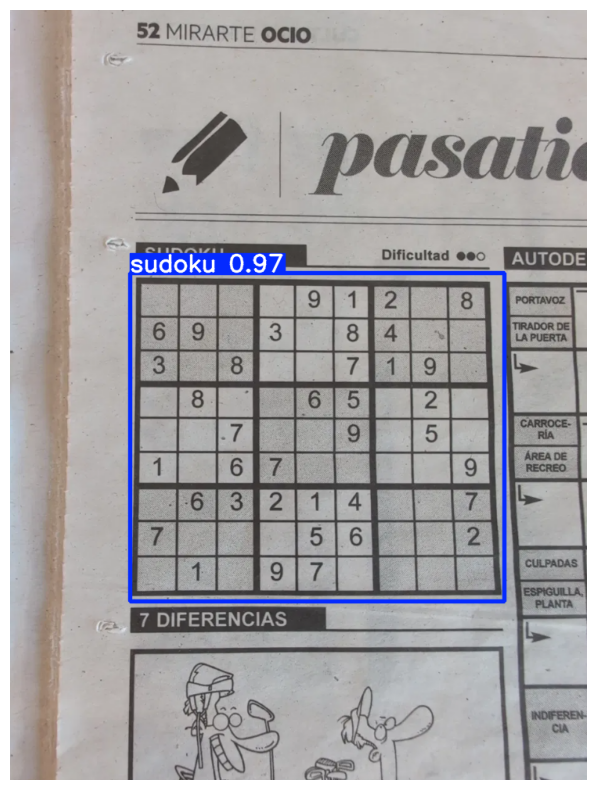

'results_001.png'

In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

modelo = YOLO('/content/runs/detect/sudoku/sudoku/weights/best.pt')

ruta_imagen = '/content/drive/MyDrive/Sudoku/001.png'

results = modelo(ruta_imagen)

img = results[0].plot()
plt.figure(figsize=(10, 10))
plt.imshow(img[..., ::-1])
plt.axis('off')
plt.show()

results[0].save()

In [13]:
!cp -r /content/runs/detect/sudoku "/content/drive/MyDrive/Sudoku/modelo_entrenado"

In [14]:
if len(results[0].boxes) == 0:
    print("No se detectó ningún recuadro de sudoku")
else:
    x1, y1, x2, y2 = map(int, results[0].boxes.xyxy[0])
    print(x1, y1, x2, y2)

153 336 631 756


In [16]:
 img_recortada = results[0].orig_img[y1:y2, x1:x2]

In [18]:
print(results[0].orig_img.shape)
print(img_recortada.shape)

(985, 737, 3)
(420, 478, 3)


In [20]:
import cv2

cv2.imwrite("img_recortada.png", img_recortada)

True

In [22]:
alto, ancho = img_recortada.shape[:2]
celda_alto = alto // 9
celda_ancho = ancho // 9

MARGEN = 4

celdas = []
for fila in range(9):
    fila_celdas = []
    for col in range(9):
        y1 = fila * celda_alto + MARGEN
        y2 = y1 + celda_alto - MARGEN * 2
        x1 = col * celda_ancho + MARGEN
        x2 = x1 + celda_ancho - MARGEN * 2
        celda = img_recortada[y1:y2, x1:x2]
        fila_celdas.append(celda)
    celdas.append(fila_celdas)

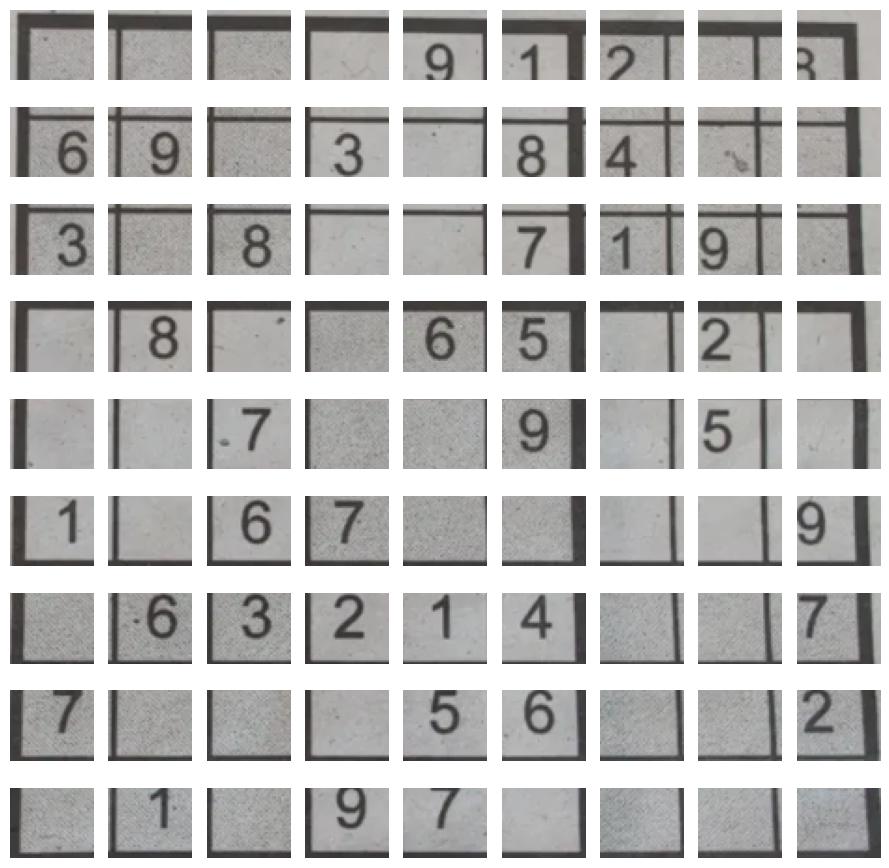

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(9, 9, figsize=(9, 9))
for fila in range(9):
    for col in range(9):
        celda_rgb = cv2.cvtColor(celdas[fila][col], cv2.COLOR_BGR2RGB)
        axes[fila][col].imshow(celda_rgb)
        axes[fila][col].axis('off')

plt.tight_layout()
plt.show()

In [25]:
from google.colab import files

plt.savefig("sudoku_grid.png")
files.download("sudoku_grid.png")  # la descarga a tu PC

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [37]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 33.7 MB/s eta 0:00:00


In [38]:
import easyocr
reader = easyocr.Reader(['en'])

def predecir_celda(celda):
    gris = cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
    resultado = reader.readtext(gris, allowlist='123456789', detail=1)

    if not resultado:
        return 0, 0.0

    texto = resultado[0][1]
    confianza = resultado[0][2]

    if texto.isdigit() and 1 <= int(texto) <= 9:
        return int(texto), confianza
    return 0, 0.0

def celda_vacia(celda):
    gris = cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
    return np.mean(gris) > 200

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [39]:
sudoku = []
for fila in range(9):
    fila_nums = []
    for col in range(9):
        digito, confianza = predecir_celda(celdas[fila][col])
        fila_nums.append(digito)
    sudoku.append(fila_nums)

print("Sudoku detectado:")
print("─" * 25)
for i, fila in enumerate(sudoku):
    if i % 3 == 0 and i != 0:
        print("─" * 25)
    fila_str = ""
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0:
            fila_str += "│ "
        fila_str += f"{num} "
    print(fila_str)

Sudoku detectado:
─────────────────────────
0 0 0 │ 0 0 0 │ 0 0 0 
0 0 0 │ 3 0 0 │ 0 0 0 
0 0 8 │ 0 0 0 │ 0 9 0 
─────────────────────────
0 8 0 │ 0 6 5 │ 0 2 0 
0 0 0 │ 0 0 9 │ 0 5 0 
0 0 6 │ 0 0 0 │ 0 0 9 
─────────────────────────
0 6 3 │ 2 0 0 │ 0 0 0 
0 0 0 │ 0 5 6 │ 0 0 2 
0 0 0 │ 9 0 0 │ 0 0 0 
